# Chroma → SpatialData

`cpio.read_plate` reads one plate of a Cell Painting Gallery source into a [SpatialData](https://spatialdata.scverse.org) object.
Fields of view become Images, the CellProfiler Nuclei, Cells and Cytoplasm segmentations become Labels, the wells become Shapes, and the well- and cell-level measurements become the `wells` and `cells` Tables.

Objects are Labels rather than Shapes because CellProfiler is pixel-based: it measures on masks, so a polygon would be a lossy conversion.
The gallery publishes one-pixel outlines rather than masks, so the labels are reconstructed from them and carry CellProfiler's own object numbers, which is what lets the `cells` table annotate them.

`cpg0029-chroma-pilot` tests alternative dyes, so it carries eight channels rather than the usual five or six: the Cell Painting set plus `Actin`, `Brightfield` and `Phase`.
`read_plate` takes the channel names from `load_data.csv`, so nothing needs saying about them here.

It also names its images with `FileName_Orig*` and `PathName_Orig*` rather than an `URL_Orig*` S3 URI, and the paths point at wherever the images sat when CellProfiler ran.
Both forms end in the gallery's own layout, which is what `read_plate` matches on.

One well of `cpg0029-chroma-pilot`, fetched with the script beside this notebook:

```bash
python fetch.py cpg0029-chroma-pilot/broad 2023_05_15_Batch1 BR00122246 A01
```

In [1]:
from __future__ import annotations

import logging
import warnings
from pathlib import Path

import numpy as np
import spatialdata as sd
import spatialdata_plot  # noqa: F401
from matplotlib.colors import Normalize

import cell_painting_io as cpio

# ome-zarr logs a line per label element on read, and spatialdata-plot warns once per element it subsets out
logging.getLogger("ome_zarr").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message="The table is annotating .*, which is not present")

DATA_ROOT = Path("~/data/cpg0029-chroma-pilot/broad").expanduser()
BATCH = "2023_05_15_Batch1"
PLATE = "BR00122246"


def grey(sdata, element, channel="DNA"):
    values = sd.get_pyramid_levels(sdata[element], n=0).sel(c=channel).to_numpy()
    return {
        "channel": channel,
        "cmap": "gray",
        "norm": Normalize(*np.percentile(values, [50, 99.9])),
        "colorbar": False,
    }

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sdata = cpio.read_plate(DATA_ROOT, BATCH, PLATE)
sdata

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


SpatialData object
├── Images
│     ├── 'BR00122246_A01_s1_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00122246_A01_s2_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00122246_A01_s3_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00122246_A01_s4_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00122246_A01_s5_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00122246_A01_s6_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00122246_A01_s7_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     ├── 'BR00122246_A01_s8_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
│     └── 'BR00122246_A01_s9_image': DataTree[cyx] (8, 1080, 1080), (8, 540, 540), (8, 270, 270)
├── Labels
│     ├── 'BR00122246_A01_s1_cells': DataArray[yx] (1080, 1080)
│     ├── 'BR00122246_

In [3]:
sd.get_pyramid_levels(sdata[f"{PLATE}_A01_s1_image"], n=0).coords["c"].to_numpy()

array(['RNA', 'ER', 'AGP', 'Mito', 'Brightfield', 'Phase', 'DNA', 'Actin'],
      dtype='<U11')

The well mosaic, then the cell masks of one field over the Actin channel this pilot added, coloured by a column of the cell table.

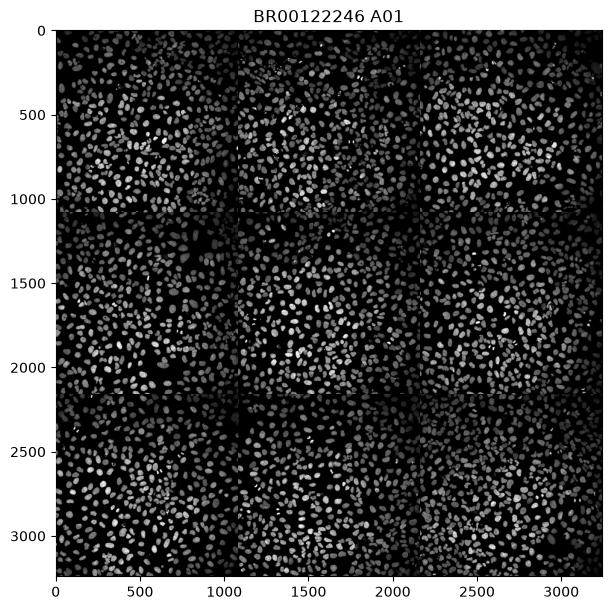

In [4]:
(
    sdata.pl.render_images(**grey(sdata, f"{PLATE}_A01_s1_image")).pl.show(
        coordinate_systems=f"{PLATE}_A01", figsize=(6, 6), title=f"{PLATE} A01"
    )
)

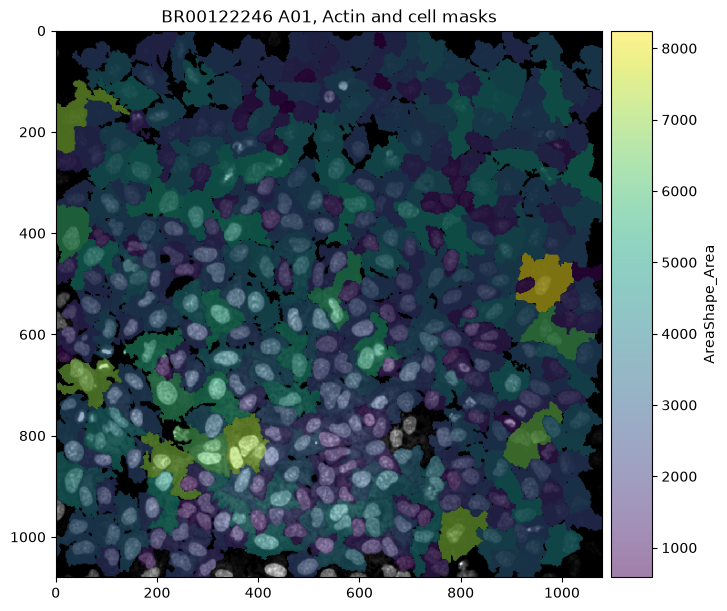

In [5]:
element = f"{PLATE}_A01_s1_image"
(
    sdata.pl.render_images(element, **grey(sdata, element, channel="Actin"))
    .pl.render_labels(f"{PLATE}_A01_s1_cells", color="AreaShape_Area", table_name="cells", fill_alpha=0.5)
    .pl.show(coordinate_systems=f"{PLATE}_A01_s1", figsize=(6.5, 6), title=f"{PLATE} A01, Actin and cell masks")
)